In [19]:
# ╔══════════════════════════════════════════════════════════╗
# ║             Model Training & Compare Models              ║
# ╚══════════════════════════════════════════════════════════╝

In [20]:

# ── Imports Libraries ───────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import os

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.tree import DecisionTreeRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid")

In [21]:
# ── Load Data ─────────────────────────────────────
df = pd.read_csv("../dataset/processed/housing_featured.csv")
df.head()

,City,Number_Beds,Number_Baths,Latitude,Longitude,Bath_Bed_Ratio,Log_Income,Log_Population,Province_Code,Log_Price
0,Toronto,3.0,2.0,43.7417,-79.3733,0.500000,11.482477,15.546751,6,13.566922
1,Toronto,3.0,1.0,43.7417,-79.3733,0.250000,11.482477,15.546751,6,13.592367
2,Toronto,2.0,2.0,43.7417,-79.3733,0.666667,11.482477,15.546751,6,13.592243
3,Toronto,4.0,2.0,43.7417,-79.3733,0.400000,11.482477,15.546751,6,13.997833
4,Toronto,1.0,1.0,43.7417,-79.3733,0.500000,11.482477,15.546751,6,13.413242


In [22]:
# ── Features & Target ─────────────────────────────
X = df[["Number_Beds", "Number_Baths", "Latitude", "Longitude",
        "Bath_Bed_Ratio", "Log_Income", "Log_Population",
        "Province_Code", "City"]] # City is categorical, will be handled in modeling

y = df["Log_Price"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (26646, 9)
y shape: (26646,)


In [23]:
# ── Train / Test Split ────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"X Train : {X_train.shape}")
print(f"Y Train : {y_train.shape}")
print(f"X Test  : {X_test.shape}")
print(f"Y Test  : {y_test.shape}")

X Train : (21316, 9)
Y Train : (21316,)
X Test  : (5330, 9)
Y Test  : (5330,)


In [24]:
# ── Calculate encodings ONLY from train data ──────────────
city_price_map  = X_train.copy()
city_price_map["Log_Price"] = y_train

city_median = city_price_map.groupby("City")["Log_Price"].median()
city_std    = city_price_map.groupby("City")["Log_Price"].std()

# Apply to train
X_train["City_Encoded"]   = X_train["City"].map(city_median)
X_train["City_Price_Std"] = X_train["City"].map(city_std)
X_train["City_Price_Rank"]= X_train.groupby("City")["City_Encoded"].rank(pct=True)

# Apply same map to test ← no test data used in calculation
X_test["City_Encoded"]    = X_test["City"].map(city_median)
X_test["City_Price_Std"]  = X_test["City"].map(city_std)
X_test["City_Price_Rank"] = X_test["City"].map(city_median).rank(pct=True)

# Drop City text column
X_train.drop(columns=["City"], inplace=True)
X_test.drop(columns=["City"],  inplace=True)

print("✅ Encodings calculated from training data only")

✅ Encodings calculated from training data only


In [25]:
X_train.head()

,Number_Beds,Number_Baths,Latitude,Longitude,Bath_Bed_Ratio,Log_Income,Log_Population,Province_Code,City_Encoded,City_Price_Std,City_Price_Rank
3571,3.0,4.0,53.5344,-113.4903,1.000000,11.472114,13.956694,0,12.834417,0.623995,0.500602
14040,4.0,3.0,44.3711,-79.6769,0.600000,11.482477,11.949094,6,13.651226,0.461937,0.500727
9349,4.0,3.0,43.9000,-78.8500,0.600000,11.532738,12.724718,6,13.710040,0.405180,0.500732
12147,4.0,2.0,52.1333,-106.6833,0.400000,11.396403,12.491785,8,12.971310,0.597673,0.500917
10574,5.0,2.0,48.4283,-123.3647,0.333333,11.350418,12.802772,1,13.815512,0.596735,0.500588


In [26]:
# ── Define All Models ─────────────────────────────
models = {
    "Random Forest": RandomForestRegressor(
        n_estimators=100, 
        random_state=42
    ),
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=100,         
        random_state=42
    ),
    "Decision Tree": DecisionTreeRegressor(
        random_state=42
    ),
    "AdaBoost Regression": AdaBoostRegressor(),
    "XGB Regression": XGBRegressor()
}

In [27]:
# ── Train & Evaluate All Models ──────────────────
results = []

for name, model in models.items():
    # Train
    model.fit(X_train, y_train)

    # Predict
    preds      = model.predict(X_test)
    preds_real = np.expm1(preds)
    y_real     = np.expm1(y_test)

    # Metrics
    mae  = mean_absolute_error(y_real, preds_real)
    rmse = np.sqrt(mean_squared_error(y_real, preds_real))
    r2   = r2_score(y_real, preds_real)
    mape = np.mean(np.abs((y_real - preds_real) / y_real)) * 100

    # CV Score
    cv   = cross_val_score(model, X_train, y_train, cv=5, scoring="r2", n_jobs=-1).mean()

    results.append({
        "Model": name,
        "MAE ($)": round(mae),
        "RMSE ($)": round(rmse),
        "R²": round(r2, 4),
        "MAPE (%)": round(mape, 2),
        "CV R²": round(cv, 4),
    })

    print(f"✅ {name:25s} MAE: ${mae:,.0f}  RMSE: ${rmse:,.0f}  R²: {r2:.4f}  MAPE: {mape:.2f}%  CV R²: {cv:.4f}")

✅ Random Forest             MAE: $301,459  RMSE: $537,475  R²: 0.5148  MAPE: 30.50%  CV R²: 0.6598
✅ Gradient Boosting         MAE: $291,833  RMSE: $526,915  R²: 0.5337  MAPE: 29.59%  CV R²: 0.6696
✅ Decision Tree             MAE: $322,434  RMSE: $566,654  R²: 0.4607  MAPE: 32.54%  CV R²: 0.6494
✅ AdaBoost Regression       MAE: $337,554  RMSE: $584,206  R²: 0.4268  MAPE: 37.04%  CV R²: 0.5808
✅ XGB Regression            MAE: $313,385  RMSE: $563,347  R²: 0.4670  MAPE: 30.72%  CV R²: 0.6633


In [28]:
# ── Comparison Table ──────────────────────────────
results_df = pd.DataFrame(results).sort_values("R²", ascending=False).reset_index(drop=True)
print("\n── Model Comparison ──")
print(results_df.to_string(index=False))


── Model Comparison ──
              Model  MAE ($)  RMSE ($)     R²  MAPE (%)  CV R²
  Gradient Boosting   291833    526915 0.5337     29.59 0.6696
      Random Forest   301459    537475 0.5148     30.50 0.6598
     XGB Regression   313385    563347 0.4670     30.72 0.6633
      Decision Tree   322434    566654 0.4607     32.54 0.6494
AdaBoost Regression   337554    584206 0.4268     37.04 0.5808


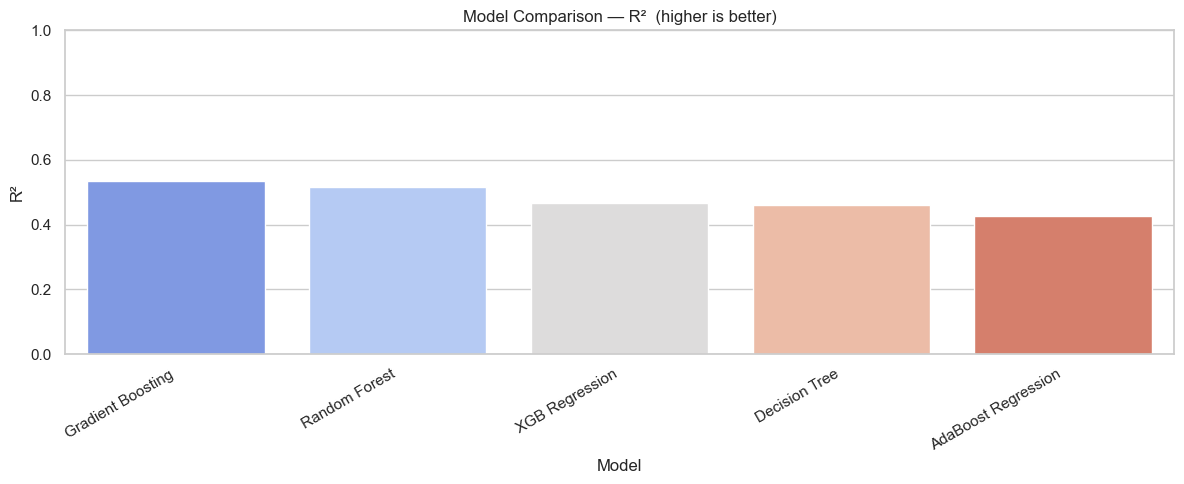

In [11]:
# ── R² Comparison Bar Plot ───────────────────────
plt.figure(figsize=(12, 5))
sns.barplot(x="Model", y="R²", data=results_df, hue='Model', palette="coolwarm")
plt.title("Model Comparison — R²  (higher is better)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
os.makedirs("../plots", exist_ok=True)
plt.savefig("../plots/11_r2_comparison.png", dpi=150)
plt.show()

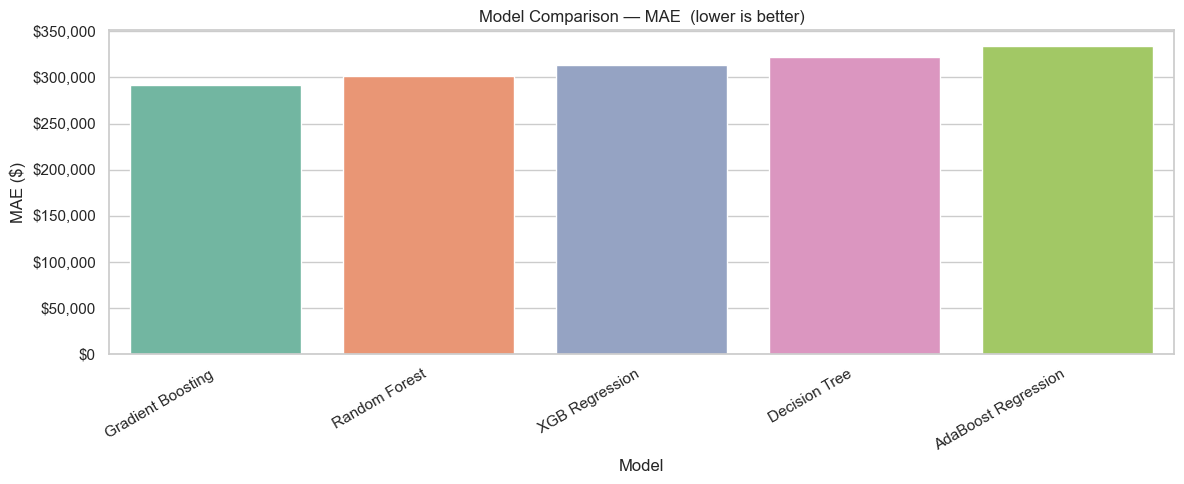

In [12]:
# ── MAE Comparison Bar Plot ──────────────────────
plt.figure(figsize=(12, 5))
sns.barplot(x="Model", y="MAE ($)", hue="Model", data=results_df, palette="Set2")
plt.title("Model Comparison — MAE  (lower is better)")
plt.xticks(rotation=30, ha="right")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"${x:,.0f}"))
plt.tight_layout()
plt.savefig("../plots/12_mae_comparison.png", dpi=150)
plt.show()

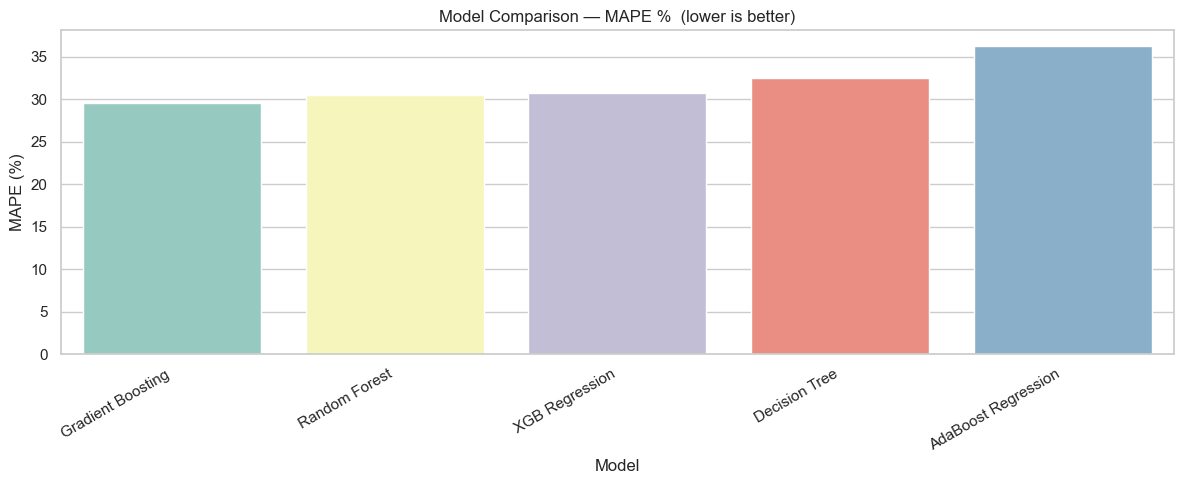

In [13]:
# ── MAPE Comparison Bar Plot ────────────────────
plt.figure(figsize=(12, 5))
sns.barplot(x="Model", y="MAPE (%)", hue="Model", data=results_df, palette="Set3")
plt.title("Model Comparison — MAPE %  (lower is better)")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("../plots/13_mape_comparison.png", dpi=150)
plt.show()

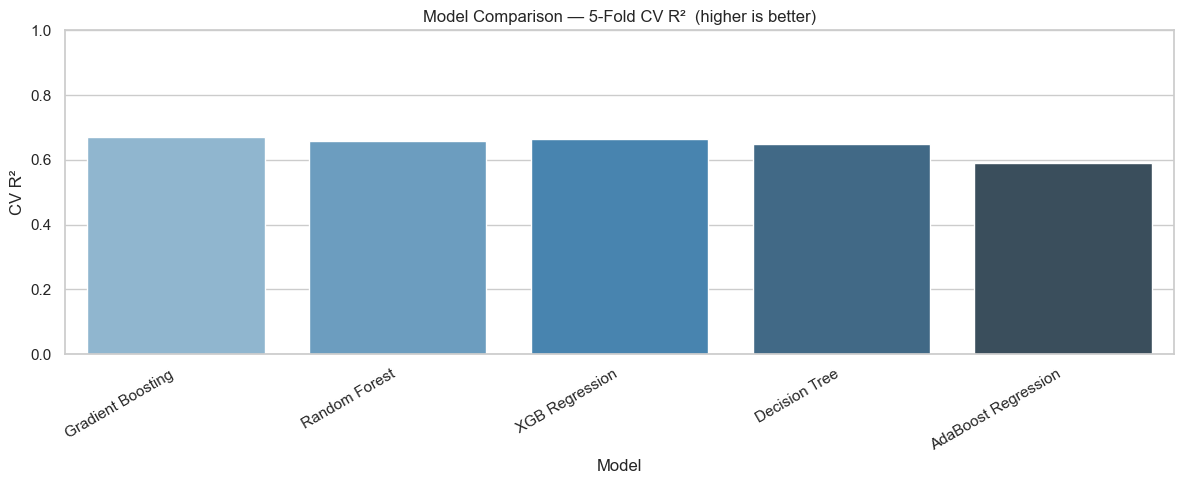

In [14]:
# ── CV R² Comparison ────────────────────────────
plt.figure(figsize=(12, 5))
sns.barplot(x="Model", y="CV R²", hue="Model", data=results_df, palette="Blues_d")
plt.title("Model Comparison — 5-Fold CV R²  (higher is better)")
plt.xticks(rotation=30, ha="right")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig("../plots/14_cv_r2_comparison.png", dpi=150)
plt.show()

In [29]:
# ── Pick Best Model ──────────────────────────────
best_name  = results_df.iloc[0]["Model"]
best_model = models[best_name]

print(f"\n🏆 Best Model : {best_name}")
print(f"   R²         : {results_df.iloc[0]['R²']}")
print(f"   MAE        : ${results_df.iloc[0]['MAE ($)']:,}")
print(f"   MAPE       : {results_df.iloc[0]['MAPE (%)']:.2f}%")


🏆 Best Model : Gradient Boosting
   R²         : 0.5337
   MAE        : $291,833
   MAPE       : 29.59%


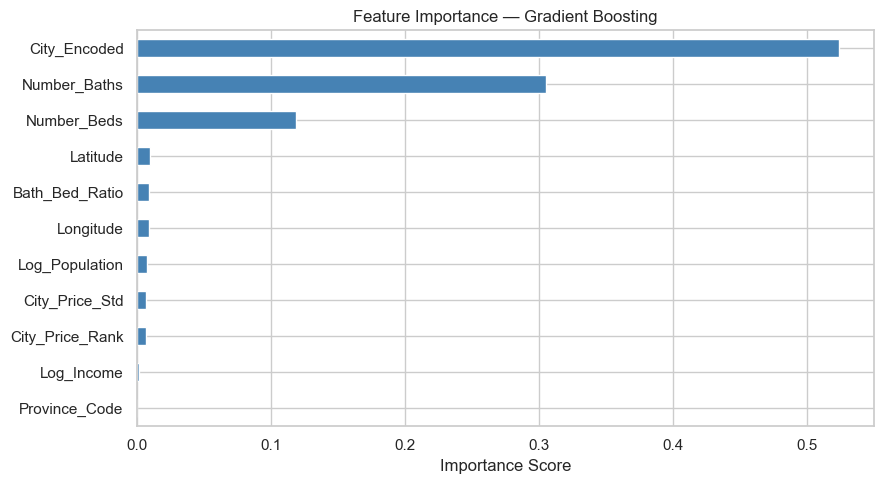

In [16]:
# ── Feature Importance (tree models only) ────────
if hasattr(best_model, "feature_importances_"):
    feature_names = X_train.columns.tolist()
    fi = pd.Series(best_model.feature_importances_, index=feature_names).sort_values()
    plt.figure(figsize=(9, 5))
    fi.plot(kind="barh", color="steelblue")
    plt.title(f"Feature Importance — {best_name}")
    plt.xlabel("Importance Score")
    plt.tight_layout()
    plt.savefig("../plots/15_feature_importance.png", dpi=150)
    plt.show()

In [17]:
# ── Save Best Model & Artifacts ─────────────────
feature_names = X_train.columns.tolist()

joblib.dump(best_model, "../models/house_price_model.pkl")
joblib.dump(feature_names,   "../models/model_features.pkl")
results_df.to_csv("../models/model_comparison.csv", index=False)

In [31]:
import pickle

# Save model and features with pickle instead of joblib
with open("../models/house_price_model.pkl", "wb") as f:
    pickle.dump(best_model, f)
    
with open("../models/model_features.pkl", "wb") as f:
    pickle.dump(feature_names, f)

print("✅ Model and Features saved with pickle")

results_df.to_csv("../models/model_comparison.csv", index=False)

✅ Model and Features saved with pickle


In [18]:
# Save train/test splits for testing notebook
X_train.to_csv("../dataset/train_test/X_train.csv", index=False)
X_test.to_csv("../dataset/train_test/X_test.csv",   index=False)
y_train.to_csv("../dataset/train_test/y_train.csv", index=False)
y_test.to_csv("../dataset/train_test/y_test.csv",   index=False)

print(f"\n✅ Best model saved  → models/house_price_model.pkl  ({best_name})")
print("✅ Saved → models/model_features.pkl")
print("✅ Saved → models/model_comparison.csv")
print("✅ Saved → dataset/train_test, X_train, X_test, y_train, y_test")


✅ Best model saved  → models/house_price_model.pkl  (Gradient Boosting)
✅ Saved → models/model_features.pkl
✅ Saved → models/model_comparison.csv
✅ Saved → dataset/train_test, X_train, X_test, y_train, y_test
